# Regression Example in Keras
Predicting house prices in Boston, Massachusetts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/the-deep-learners/deep-learning-illustrated/blob/master/notebooks/regression_in_keras.ipynb)

#### Load dependencies

In [2]:
import numpy as np
from tensorflow.keras.datasets import boston_housing
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

#### Load data

In [7]:
(X_train, y_train), (X_valid, y_valid) = boston_housing.load_data()
X_train.shape, X_valid.shape

((404, 13), (102, 13))

In [6]:
import pandas as pd
df = pd.DataFrame(data=X_train)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


#### Design neural network architecture

In [27]:
model = Sequential([Input(shape=(13,)),
                    Dense(32, activation='relu'),
                    BatchNormalization(),

                    Dense(16, activation='relu'),
                    BatchNormalization(),
                    Dropout(0.2),

                    Dense(1, activation='linear')]
)
# model.summary()
model.compile(loss='mean_squared_error',
              optimizer='adam',
              metrics=['accuracy']
)
history = model.fit(X_train, y_train,
                    batch_size=8,
                    epochs=50,
                    verbose=1,
                    validation_data=(X_valid, y_valid)
)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0000e+00 - loss: 580.9520 - val_accuracy: 0.0000e+00 - val_loss: 666.3752
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 557.3806 - val_accuracy: 0.0000e+00 - val_loss: 671.7355
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 537.9563 - val_accuracy: 0.0000e+00 - val_loss: 598.1235
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 509.7100 - val_accuracy: 0.0000e+00 - val_loss: 564.7464
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 486.6451 - val_accuracy: 0.0000e+00 - val_loss: 513.3133
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 461.2976 - val_accuracy: 0.0000e+00 - val_loss: 474.4763
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 421.8342 - val_accuracy: 0.0000e+00 - val_loss: 385.3391
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━

In [22]:
print(X_valid[42].shape, np.reshape(X_valid[42], [1, 13]).shape)

(13,) (1, 13)


In [21]:
print(model.predict(np.reshape(X_valid[42], [1, 13])), y_valid[42])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[12.607611]] 14.1


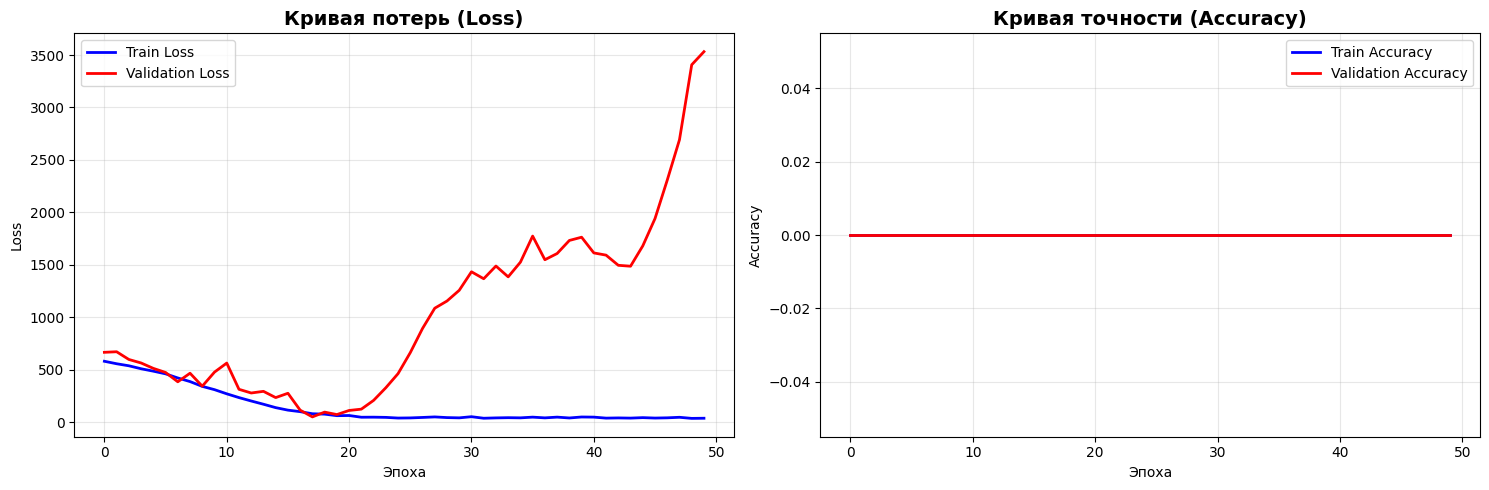


Лучшие результаты на эпохе 18:
  Train Loss: 50.7434
  Val Loss: 50.7434
  Train Accuracy: 0.0000
  Val Accuracy: 0.0000


In [28]:
import matplotlib.pyplot as plt

# Создаем графики в две колонки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Кривая потерь (loss)
ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
ax1.set_title('Кривая потерь (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Кривая точности (accuracy)
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
ax2.set_title('Кривая точности (Accuracy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительно: выводим лучшие результаты
best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
print(f"\nЛучшие результаты на эпохе {best_epoch}:")
print(f"  Train Loss: {min(history.history['val_loss']):.4f}")
print(f"  Val Loss: {min(history.history['val_loss']):.4f}")
print(f"  Train Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Val Accuracy: {max(history.history['val_accuracy']):.4f}")
